# Employee Turnover - HR Department

In [1]:
#Perform data quality checks by checking for missing values, if any. 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans



df = pd.read_csv("HR.csv")

df.info()

df['satisfaction_level'] = pd.to_numeric(df['satisfaction_level'], errors='coerce')
df['last_evaluation'] = pd.to_numeric(df['last_evaluation'], errors='coerce')
df['number_project'] = pd.to_numeric(df['number_project'], errors='coerce')
df['average_montly_hours'] = pd.to_numeric(df['average_montly_hours'], errors='coerce')
df['time_spend_company'] = pd.to_numeric(df['time_spend_company'], errors='coerce')
df['Work_accident'] = pd.to_numeric(df['Work_accident'], errors='coerce')
df['left'] = pd.to_numeric(df['left'], errors='coerce')
df['promotion_last_5years'] = pd.to_numeric(df['promotion_last_5years'], errors='coerce')

missing_values = df.isnull().sum()
print(missing_values)

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5

##### There are no null/missing values in the dataset

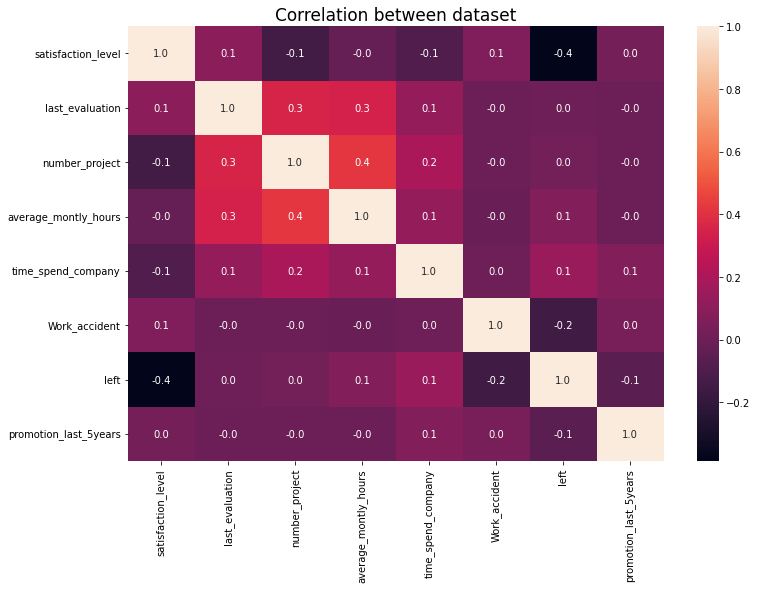

In [2]:
#Understand what factors contributed most to employee turnover at EDA. 

# 1. Heat map
plt.figure(figsize=(12,8))
c = df.corr(numeric_only=True)
sns.heatmap(c, annot=True, fmt=".1f")
plt.title("Correlation between dataset", fontsize=17, c="k")
plt.show()


# Observations

##### High Correlations: 3 pairs of feature exhibit moderate positive correletions. For example, last_evaluation, number_projects, and average_monthly_hours are moderately correlated with one another. This relationship is reasonable, as all three variables reflect aspects of employee performace and workload. Employees who work more hours may be assigned more projects, which could influence their evaluation scores. 

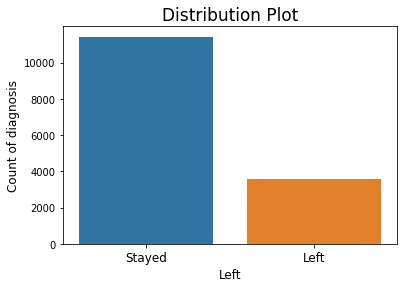

In [3]:
# Distribution plot
sns.countplot(x="left",data=df)
plt.title("Distribution Plot",fontsize=17,c="k")
plt.xlabel("Left",fontsize=12)
plt.ylabel("Count of diagnosis",fontsize=12)
plt.xticks([0, 1], ['Stayed', 'Left'], fontsize=12)
plt.show()

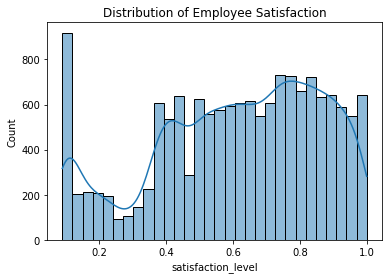

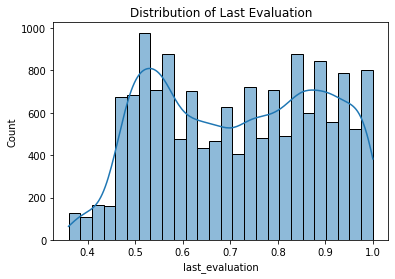

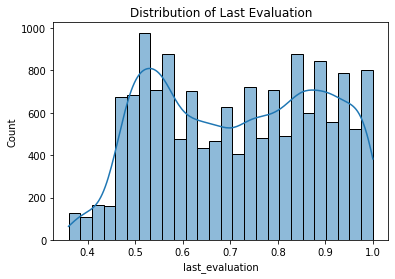

In [4]:
#Distribution Plot
sns.histplot(df['satisfaction_level'], kde=True)
plt.title('Distribution of Employee Satisfaction')
plt.show()

sns.histplot(df['last_evaluation'], kde=True)
plt.title('Distribution of Last Evaluation')
plt.show()

sns.histplot(df['last_evaluation'], kde=True)
plt.title('Distribution of Last Evaluation')
plt.show()

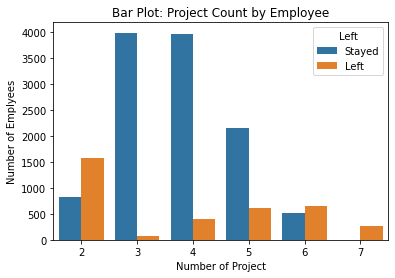

In [5]:
#Bar Plot
sns.countplot(x='number_project', hue='left', data=df)
plt.title("Bar Plot: Project Count by Employee")
plt.xlabel("Number of Project")
plt.ylabel("Number of Emplyees")
plt.legend(title="Left", labels=["Stayed", "Left"])
plt.show()

# Inferences from the Bar Plot

#### The bar plot shows that employees who stayed are most common around 3 and 4 projects, while employees who left increase at low and high project counts. This suggestd that turnover rises when employees are either underutilized or overworked. A balanced workload appears to be associated with better retention. 

In [6]:
left_df = df[df['left'] == 1].copy()
X = left_df[['satisfaction_level', 'last_evaluation']].values

kmeans = KMeans(n_clusters = 3, n_init = 10, init = 'k-means++', random_state = 42)
left_df['cluster'] = kmeans.fit_predict(X)
left_df.groupby('cluster')[['satisfaction_level','last_evaluation']].mean()

,satisfaction_level,last_evaluation
cluster,,
0,0.410145,0.516982
1,0.808516,0.911709
2,0.111155,0.869301


# Employee cluster 
#### Cluster 0 has moderate dissatifaction and moderate positve evaluations, these employees are the "silent quitters". These emplyees are likly poor fits for the role from the beginning 

Cluster 1 has high satisfaction and high evaluation, these employees are most likely  Cluster 2 has low satisfaction and high evaluation which are most likely empolyees that do not find their work fulfulling but they are good at what they do. 

In [7]:
# Seperate variables
X = df.drop('left', axis=1)
y = df['left']

# Seperate cat and num columns
cat_columns = ['sales', 'salary']
num_columns = [col for col in X.columns if col not in cat_columns]

#Apply get_dummies
X_cat = pd.get_dummies(X[cat_columns], drop_first=True)
X_num = X[num_columns]


#Combine variables
X_final = pd.concat([X_num, X_cat], axis=1)

#Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=123, stratify=y)

# SMOTE technique
smote = SMOTE(random_state=123)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



Perform 5-fold cross-validation model training and evaluate performance. 

Train a logistic regression model, apply a 5-fold CV, and plot the classification report. 

Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report. 

Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report. 

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

#Logistic Regression
print("--- Logistic Regression ---")
log_reg = LogisticRegression(max_iter=2000, random_state=123)
y_pred_log_reg = cross_val_predict(log_reg, X_train_smote, y_train_smote, cv=cv)

report = classification_report(y_train_smote, y_pred_log_reg)
print(report)

#Random Forest Classifier
print("--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=200, random_state=123)
y_pred_rf = cross_val_predict(rf, X_train_smote, y_train_smote, cv=cv)

report_rf = classification_report(y_train_smote, y_pred_rf)
print(report_rf)

#Gradient Boosting Classifier 
print("--- Gradient Boosting ---")
gbc = GradientBoostingClassifier(random_state=123)
y_pred_gbc = cross_val_predict(gbc, X_train_smote, y_train_smote, cv=cv)

report_gbc = classification_report(y_train_smote, y_pred_gbc)
print(report_gbc)



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      9142
           1       0.77      0.82      0.80      9142

    accuracy                           0.79     18284
   macro avg       0.79      0.79      0.79     18284
weighted avg       0.79      0.79      0.79     18284

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      9142
           1       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      9142
           1       0.98      0.94      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     1828

Identify the best model and justify the evaluation metrics used. 

Find the ROC/AUC for each model and plot the ROC curve. 

Find the confusion matrix for each of the models. 

Explain which metric needs to be used from the confusion matrix: Recall or Precision? 

# Identify the best Model and justify the evaluation metrics used
Since the business objective is to minimize missed turnover cases, recall is the most important evaluation metric. Recall measures the model’s ability to correctly identify employees who are likely to leave.
Among the three models, the Random Forest Classifier demonstrates the strongest performance, achieving the highest recall for class 1 (employees who left). Specifically, Logistic Regression achieved a recall of 82%, Gradient Boosting achieved 94%, and Random Forest achieved 97%.




Logistic Regression AUC: 0.8095820130326847
Random Forest AUC: 0.9953697577018559
Gradient Boosting AUC: 0.9850070824480273


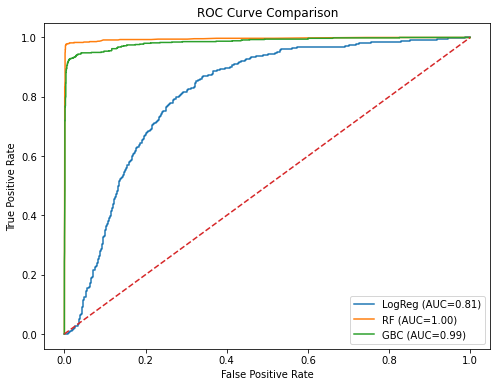

In [9]:
#Find the ROC?AUX for each model and plot the ROC curve
log_reg.fit(X_train_smote, y_train_smote)
rf.fit(X_train_smote, y_train_smote)
gbc.fit(X_train_smote, y_train_smote)

y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_gbc = gbc.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, roc_curve

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gbc = roc_auc_score(y_test, y_prob_gbc)

print("Logistic Regression AUC:", auc_log)
print("Random Forest AUC:", auc_rf)
print("Gradient Boosting AUC:", auc_gbc)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_prob_gbc)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"LogReg (AUC={auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.2f})")
plt.plot(fpr_gbc, tpr_gbc, label=f"GBC (AUC={auc_gbc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Logistic Regression:
 [[1720  566]
 [ 178  536]]

Random Forest:
 [[2263   23]
 [  15  699]]

Gradient Boosting:
 [[2222   64]
 [  45  669]]


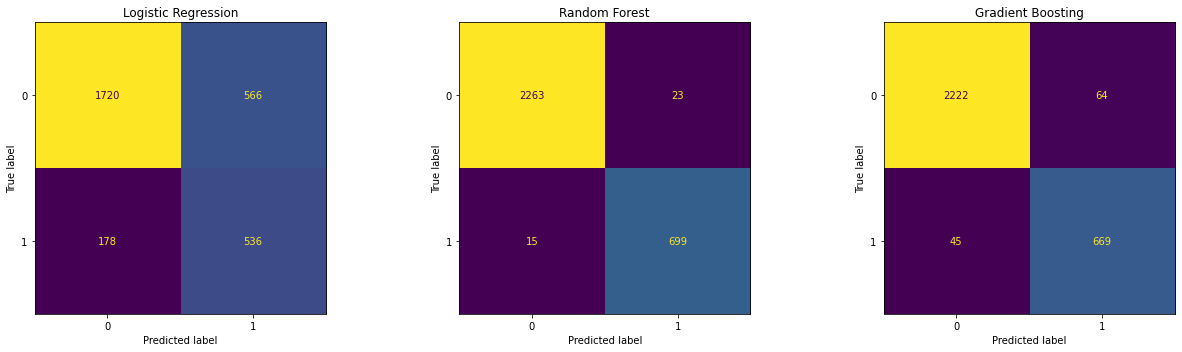

In [10]:
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gbc = gbc.predict(X_test)

from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gbc = confusion_matrix(y_test, y_pred_gbc)

print("Logistic Regression:\n", cm_log)
print("\nRandom Forest:\n", cm_rf)
print("\nGradient Boosting:\n", cm_gbc)

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18,5))

ConfusionMatrixDisplay(cm_log).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_rf).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay(cm_gbc).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Gradient Boosting")

plt.tight_layout()
plt.show()

# Which metric to be used from the confusion matrix: Recall or Precision?

#### In this problem, recall is more important than precision. Recall shows how many employees who actually left were correctly identified by the model. This matters because the goal is to catch employees who are at risk of leaving. If the model predicts that an employee will stay but they actually leave, the company misses the chance to take action, which can be costly.

In [11]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results = X_test.copy()
results['turnover_probability'] = y_prob_rf

results ['actual_left'] = y_test.values

def assign_zone(p):
    if p < 0.2:
        return "Safe (Green)"
    elif p < 0.6:
        return "Low Risk (Yellow)"
    elif p < 0.9:
        return "Medium Risk (Orange)"
    else:
        return "High Risk (Red)"

results['risk_zone'] = results['turnover_probability'].apply(assign_zone)

print(results['risk_zone']. value_counts())

Safe (Green)            2150
High Risk (Red)          657
Low Risk (Yellow)        142
Medium Risk (Orange)      51
Name: risk_zone, dtype: int64


# Retention strategies for each zone

#### Safe Zone (Green) (Score < 20%)
##### These are the "Chill greens". These empolyees aren't thinking about leaving, but we can't ignore them. Stratagy for retention: Provide growth opportunities, Reward performance, maintain current work. 
#### Low-Risk Zone (Yellow) (20% < Score < 60%)
##### These are the "Mellow disengagment". These empoyees are stable but my disengage over time, so we nede to prevent disengagement early. Retention strategy: Check in with manager, career development strategies, increase involvement. 
#### Medium-Risk Zone (Orange) (60% < Score < 90%)
##### These are the "risky oranges". these empoyees show clear signs of potential turnover, but we have to act quickly before they leave. Retention Strategy: Identify dissatisfaction drivers, improve work-life balance, and address workload. 
#### High-Risk Zone (Red) (Score > 90%)
##### These are the "ready to leave red. These employees are highly likely to leave, but we have to prevent immediate loss. Retention strategy: personalized retntion plan, benifits review, or consider role change. 

#### This approach helps the company focus on the right people at the right time instead of treating every employee the same. The goal is to catch issues early and act before it’s too late.